1. Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import pickle
import warnings
warnings.filterwarnings("ignore")

2. Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\laptop\Desktop\Medical expenses project\medical expenses.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,49,female,34.7,5,no,southwest,31359.75
1,29,male,31.1,1,no,northwest,20323.08
2,35,female,42.8,2,no,northwest,31662.24
3,24,male,28.7,0,no,northeast,13268.67
4,41,male,23.8,0,no,northwest,17539.58


In [4]:
df.shape

(15000, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       15000 non-null  int64  
 1   sex       15000 non-null  object 
 2   bmi       15000 non-null  float64
 3   children  15000 non-null  int64  
 4   smoker    15000 non-null  object 
 5   region    15000 non-null  object 
 6   charges   15000 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 820.4+ KB


3. Basic Data Checks

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.describe()

,age,bmi,children,charges
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,43.438267,29.476953,2.495800,29652.868095
std,15.016689,6.133484,1.702481,10803.037291
min,18.000000,5.500000,0.000000,3720.300000
25%,30.000000,25.400000,1.000000,22077.260000
50%,43.000000,29.500000,3.000000,27011.365000
75%,57.000000,33.600000,4.000000,34717.487500
max,69.000000,51.800000,5.000000,64927.790000


4. Exploratory Data Analysis (EDA)

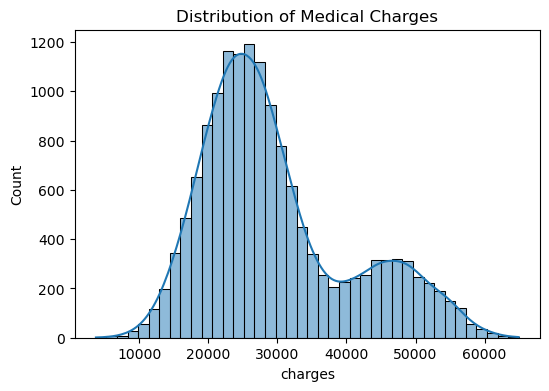

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["charges"], bins=40, kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

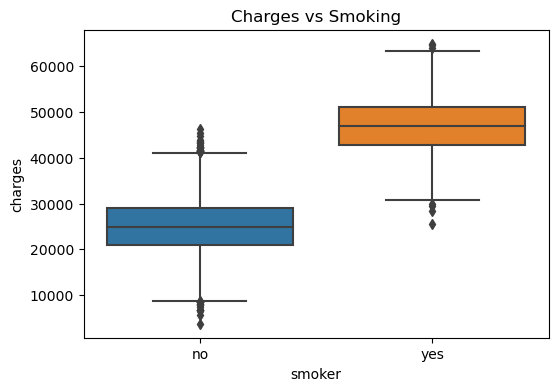

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Charges vs Smoking")
plt.show()

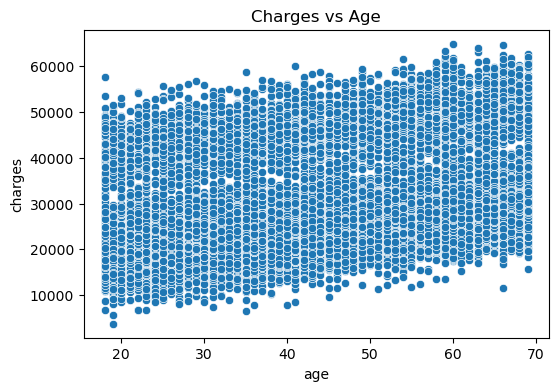

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Charges vs Age")
plt.show()

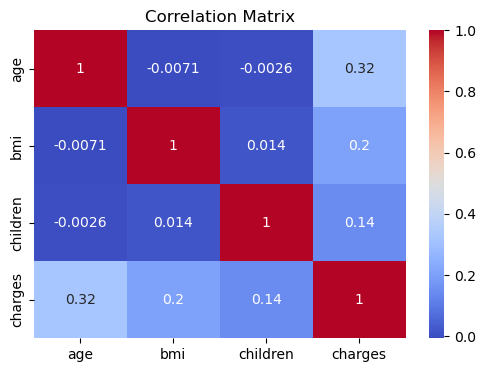

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(exclude="object").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

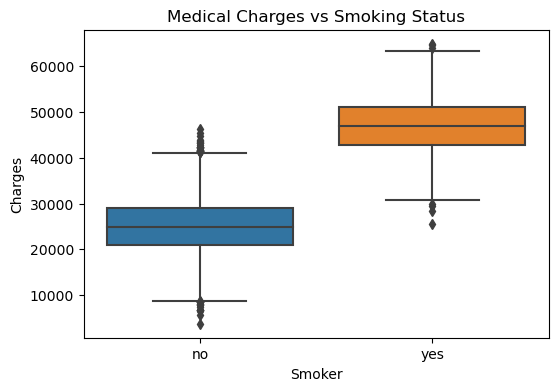

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Medical Charges vs Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

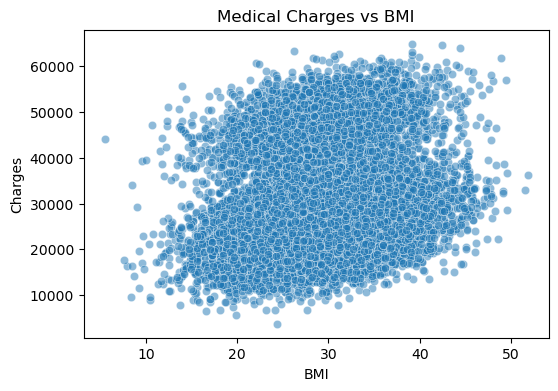

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="bmi", y="charges", data=df, alpha=0.5)
plt.title("Medical Charges vs BMI")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

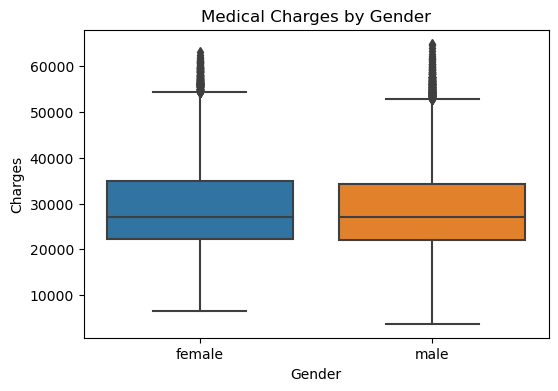

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x="sex", y="charges", data=df)
plt.title("Medical Charges by Gender")
plt.xlabel("Gender")
plt.ylabel("Charges")
plt.show()

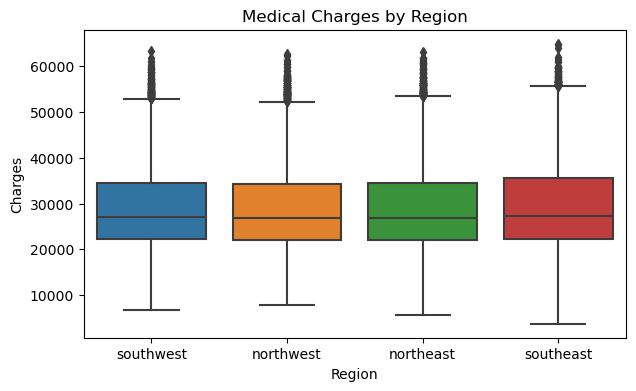

In [16]:
plt.figure(figsize=(7,4))
sns.boxplot(x="region", y="charges", data=df)
plt.title("Medical Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

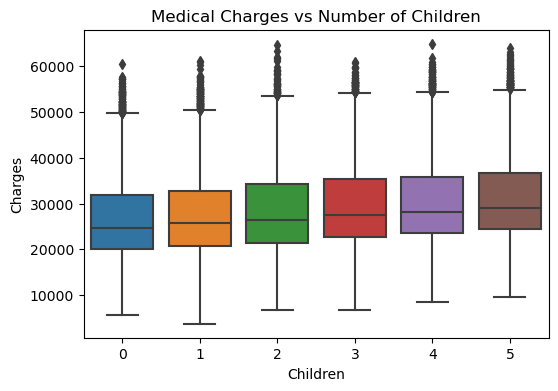

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x="children", y="charges", data=df)
plt.title("Medical Charges vs Number of Children")
plt.xlabel("Children")
plt.ylabel("Charges")
plt.show()

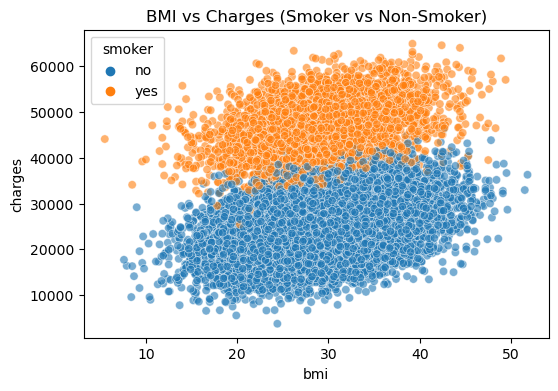

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="bmi",
    y="charges",
    hue="smoker",
    data=df,
    alpha=0.6
)
plt.title("BMI vs Charges (Smoker vs Non-Smoker)")
plt.show()

5. Train–Test Split

In [21]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

6. Feature Categorization

In [22]:
categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(exclude="object").columns

categorical_features, numerical_features

(Index(['sex', 'smoker', 'region'], dtype='object'),
 Index(['age', 'bmi', 'children'], dtype='object'))

7. Preprocessing Pipeline

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)


8. Model Selection
 Model Used:

RandomForestRegressor

Handles non-linearity

Robust to outliers

Gives feature importance

Industry friendly for tabular healthcare data

9. Full Training Pipeline

In [24]:
model = RandomForestRegressor(random_state=42)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)


10. Hyperparameter Tuning

In [26]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,   
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['age', 'bmi', 'children'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         Index(['sex', 'smoker', 'region'], dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

11. Best Model

In [27]:
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_split=5,
                                       n_estimators=200, random_state=42))])

12. Model Evaluation

In [28]:
y_pred = best_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8511225464657347
MAE: 3296.0868864825106
RMSE: 4099.599922436072


13. Feature Importance

In [29]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)


,Feature,Importance
4,cat__smoker_yes,0.781353
0,num__age,0.120265
1,num__bmi,0.067550
2,num__children,0.023311
3,cat__sex_male,0.002068
5,cat__region_northwest,0.001880
6,cat__region_southeast,0.001832
7,cat__region_southwest,0.001742


14. Feature Importance Plot

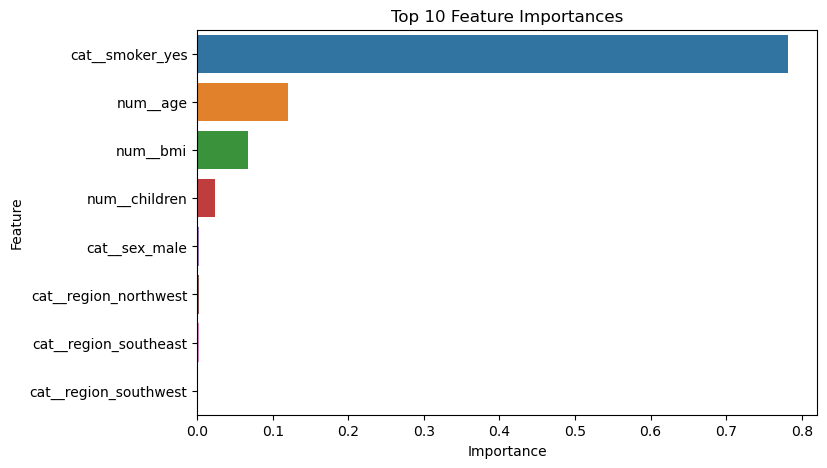

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)
plt.title("Top 10 Feature Importances")
plt.show()


In [32]:
with open("../artifact/model.pkl", "wb") as f:
    pickle.dump(best_model.named_steps["model"], f)

with open("../artifact/preprocessor.pkl", "wb") as f:
    pickle.dump(best_model.named_steps["preprocessor"], f)